### Setup: Imports, Text Loading, Model Initialization, and Query

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from numpy.linalg import norm
from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter, SentenceTransformersTokenTextSplitter

In [ ]:
# Helper function for cosine similarity
def cosine(u, v):
    return np.dot(u, v) / (norm(u)*norm(v))

In [ ]:
# Load the document text and split into words
text = open("/content/sample_doc.txt", "r").read()
words = text.split()
print(f"Document loaded. Total words: {len(words)}")

Document loaded. Total words: 163


In [ ]:
# Load the SentenceTransformer model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
print("SentenceTransformer model loaded.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

SentenceTransformer model loaded.


In [ ]:
# Define the query and get its embedding
query = "What is machine learning?"
embeding = model.encode([query])
print(f"Query: '{query}' - Embedding shape: {embeding.shape}")

Query: 'What is machine learning?' - Embedding shape: (1, 384)


### 1. Fixed-size Word Chunking (No Overlap)

In [ ]:
chunk_size = 100
chunks = []
for i in range(0, len(words), chunk_size):
  chunk = " ".join(words[i:i+chunk_size])
  chunks.append(chunk)

print(f"Total chunks generated: {len(chunks)}")
print("First chunk:")
print(chunks[0])

Total chunks generated: 2
First chunk:
Machine learning is a branch of artificial intelligence focused on building systems that learn from data. These systems improve their performance over time without being explicitly programmed. There are many applications of machine learning, such as image classification, speech recognition, recommendation systems, and autonomous driving. Supervised learning uses labeled data to train predictive models. It is commonly used for tasks like spam detection and sentiment analysis. Unsupervised learning, on the other hand, discovers hidden patterns in unlabeled data, such as customer clustering or anomaly detection. Reinforcement learning involves agents making decisions by interacting with an environment. They receive rewards or


In [ ]:
# Converting chunks into embeddings
embeddings = model.encode(chunks)
print(f"Embeddings shape: {embeddings.shape}")

Embeddings shape: (2, 384)


In [ ]:
# Similarity score calculation
scores = []
for i in range(len(chunks)):
  scores.append(cosine(embeddings[i], embeding[0]))

print("Similarity scores:")
print(scores)

Similarity scores:
[np.float32(0.68707585), np.float32(0.45566306)]


#### Visualization: Fixed-size Word Chunking

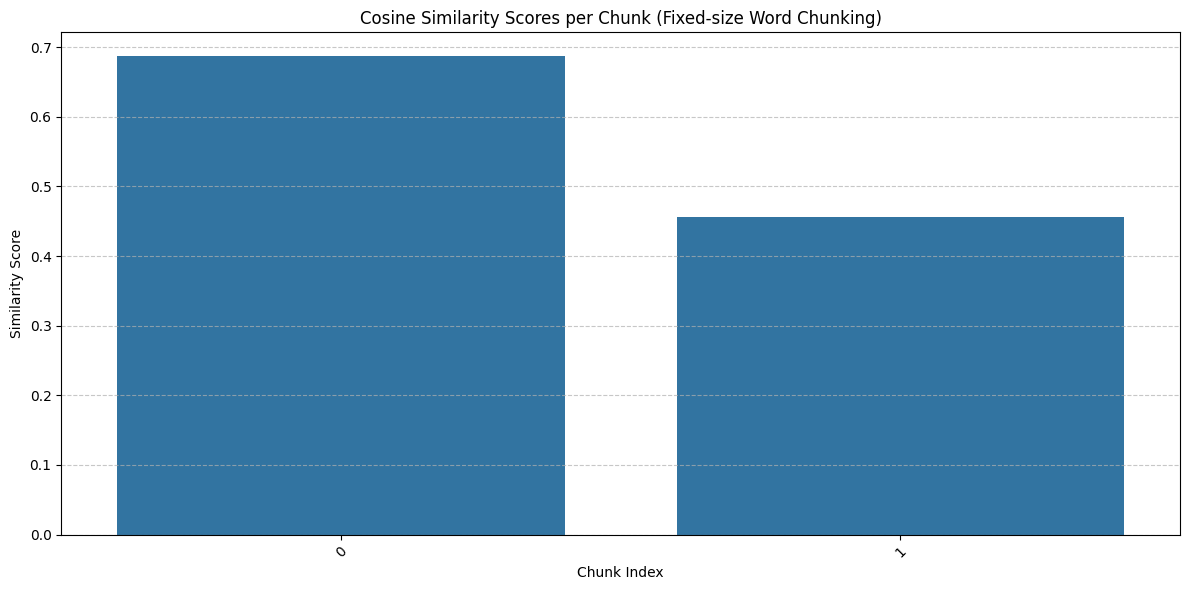

In [ ]:
df_scores = pd.DataFrame({
    'Chunk Index': range(len(scores)),
    'Similarity Score': [s for s in scores]
})

plt.figure(figsize=(12, 6))
sns.barplot(x='Chunk Index', y='Similarity Score', data=df_scores)
plt.title('Cosine Similarity Scores per Chunk (Fixed-size Word Chunking)')
plt.xlabel('Chunk Index')
plt.ylabel('Similarity Score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2. Fixed-size Word Chunking (With Overlap)

In [ ]:
new_chunk_size = 50
chunk_overlap = 10

chunks_overlap = []
for i in range(0, len(words), new_chunk_size - chunk_overlap):
    chunk = " ".join(words[i : i + new_chunk_size])
    chunks_overlap.append(chunk)

print(f"Total chunks generated with overlap: {len(chunks_overlap)}")
print("First chunk with overlap:")
print(chunks_overlap[0])
print("Second chunk with overlap:")
print(chunks_overlap[1])

Total chunks generated with overlap: 5
First chunk with overlap:
Machine learning is a branch of artificial intelligence focused on building systems that learn from data. These systems improve their performance over time without being explicitly programmed. There are many applications of machine learning, such as image classification, speech recognition, recommendation systems, and autonomous driving. Supervised learning uses labeled data
Second chunk with overlap:
recommendation systems, and autonomous driving. Supervised learning uses labeled data to train predictive models. It is commonly used for tasks like spam detection and sentiment analysis. Unsupervised learning, on the other hand, discovers hidden patterns in unlabeled data, such as customer clustering or anomaly detection. Reinforcement learning involves agents making


In [ ]:
# Converting the new chunks (with overlap) into embeddings
embeddings_overlap = model.encode(chunks_overlap)
print(f"Embeddings shape: {embeddings_overlap.shape}")

Embeddings shape: (5, 384)


In [ ]:
# Similarity score calculation for chunks with overlap
scores_overlap = []
for i in range(len(chunks_overlap)):
  scores_overlap.append(cosine(embeddings_overlap[i], embeding[0]))

print("Similarity scores with overlap:")
print(scores_overlap)

Similarity scores with overlap:
[np.float32(0.79181707), np.float32(0.5304578), np.float32(0.5149866), np.float32(0.59838563), np.float32(0.21405059)]


#### Visualization: Fixed-size Word Chunking with Overlap

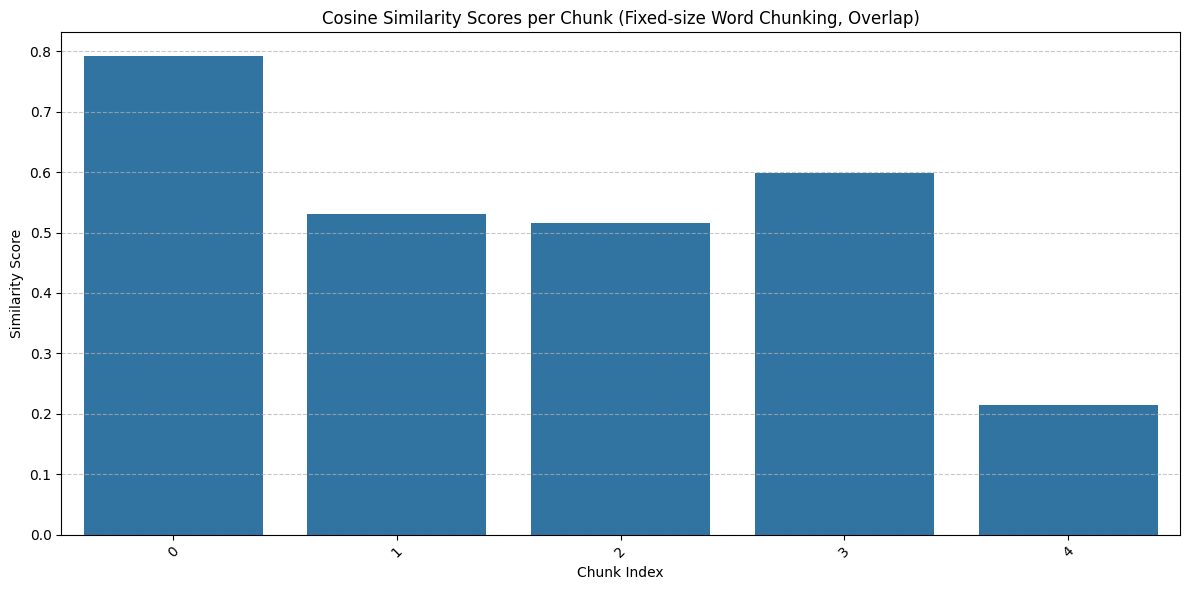

In [ ]:
df_scores_overlap = pd.DataFrame({
    'Chunk Index': range(len(scores_overlap)),
    'Similarity Score': [s for s in scores_overlap]
})

plt.figure(figsize=(12, 6))
sns.barplot(x='Chunk Index', y='Similarity Score', data=df_scores_overlap)
plt.title('Cosine Similarity Scores per Chunk (Fixed-size Word Chunking, Overlap)')
plt.xlabel('Chunk Index')
plt.ylabel('Similarity Score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 3. Recursive Character Text Splitter

In [ ]:
# Initialize RecursiveCharacterTextSplitter
recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=20,
    length_function=len,
    is_separator_regex=False,
)

# Split the document into chunks
recursive_chunks = recursive_splitter.create_documents([text])

print(f"Total chunks generated with RecursiveCharacterTextSplitter: {len(recursive_chunks)}")
print("First recursive chunk:")
print(recursive_chunks[0].page_content)
print("Second recursive chunk:")
print(recursive_chunks[1].page_content)

Total chunks generated with RecursiveCharacterTextSplitter: 16
First recursive chunk:
Machine learning is a branch of artificial intelligence focused on building systems that learn from
Second recursive chunk:
that learn from data. These systems improve their performance over time without being explicitly


In [ ]:
# Converting the recursive chunks into embeddings
recursive_chunk_texts = [doc.page_content for doc in recursive_chunks]
embeddings_recursive = model.encode(recursive_chunk_texts)
print(f"Embeddings shape: {embeddings_recursive.shape}")

Embeddings shape: (16, 384)


In [ ]:
# Similarity score calculation for recursive chunks
scores_recursive = []
for i in range(len(recursive_chunks)):
  scores_recursive.append(cosine(embeddings_recursive[i], embeding[0]))

print("Similarity scores with RecursiveCharacterTextSplitter:")
print(scores_recursive)

Similarity scores with RecursiveCharacterTextSplitter:
[np.float32(0.729389), np.float32(0.4490623), np.float32(0.67384845), np.float32(0.43302983), np.float32(0.5761595), np.float32(0.4474411), np.float32(0.33784363), np.float32(0.35534146), np.float32(0.3751625), np.float32(0.24443679), np.float32(0.15298223), np.float32(0.2508078), np.float32(0.6422348), np.float32(0.5169004), np.float32(0.29581714), np.float32(0.3322263)]


#### Visualization: Recursive Character Text Splitter

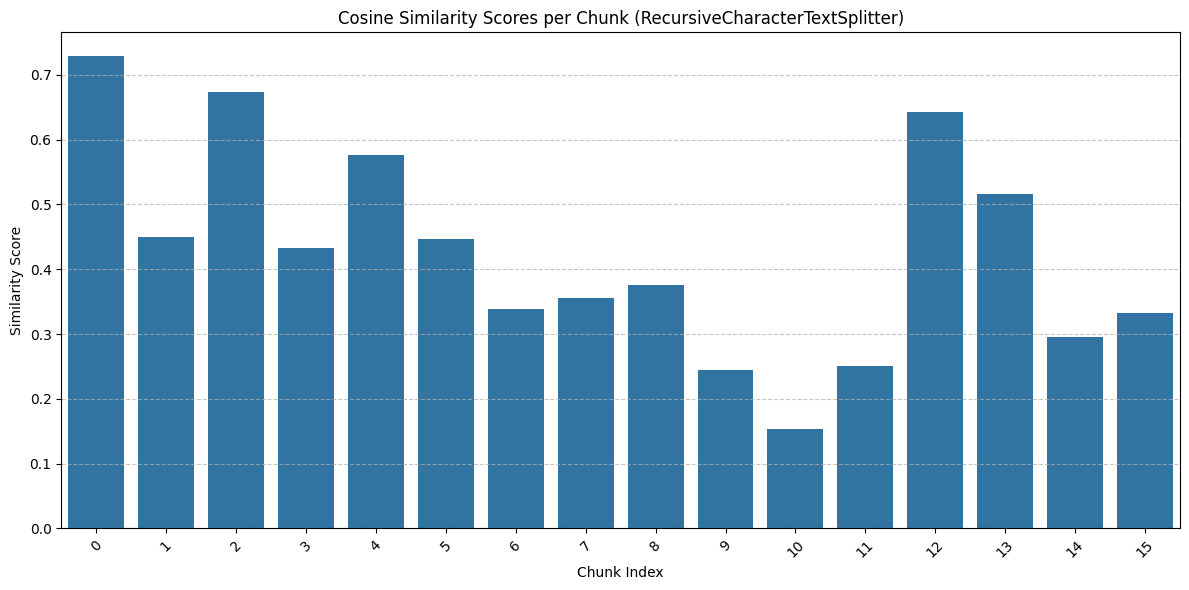

In [ ]:
df_scores_recursive = pd.DataFrame({
    'Chunk Index': range(len(scores_recursive)),
    'Similarity Score': [s for s in scores_recursive]
})

plt.figure(figsize=(12, 6))
sns.barplot(x='Chunk Index', y='Similarity Score', data=df_scores_recursive)
plt.title('Cosine Similarity Scores per Chunk (RecursiveCharacterTextSplitter)')
plt.xlabel('Chunk Index')
plt.ylabel('Similarity Score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 4. SentenceTransformers Token Text Splitter

In [ ]:
# Initialize SentenceTransformersTokenTextSplitter
sentence_transformer_splitter = SentenceTransformersTokenTextSplitter(
    chunk_overlap=20,
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    tokens_per_chunk=100
)

# Split the document into chunks
sentence_chunks = sentence_transformer_splitter.split_text(text)

print(f"Total chunks generated with SentenceTransformersTokenTextSplitter: {len(sentence_chunks)}")
print("First sentence transformer chunk:")
print(sentence_chunks[0])
print("Second sentence transformer chunk:")
print(sentence_chunks[1])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Total chunks generated with SentenceTransformersTokenTextSplitter: 3
First sentence transformer chunk:
machine learning is a branch of artificial intelligence focused on building systems that learn from data. these systems improve their performance over time without being explicitly programmed. there are many applications of machine learning, such as image classification, speech recognition, recommendation systems, and autonomous driving. supervised learning uses labeled data to train predictive models. it is commonly used for tasks like spam detection and sentiment analysis. unsupervised learning, on the other hand, discovers hidden patterns in unlabeled data, such
Second sentence transformer chunk:
##vised learning, on the other hand, discovers hidden patterns in unlabeled data, such as customer clustering or anomaly detection. reinforcement learning involves agents making decisions by interacting with an environment. they receive rewards or penalties based on their actions and learn

In [ ]:
# Converting the sentence transformer chunks into embeddings
embeddings_sentence = model.encode(sentence_chunks)
print(f"Embeddings shape: {embeddings_sentence.shape}")

Embeddings shape: (3, 384)


In [ ]:
# Similarity score calculation for sentence transformer chunks
scores_sentence = []
for i in range(len(sentence_chunks)):
  scores_sentence.append(cosine(embeddings_sentence[i], embeding[0]))

print("Similarity scores with SentenceTransformersTokenTextSplitter:")
print(scores_sentence)

Similarity scores with SentenceTransformersTokenTextSplitter:
[np.float32(0.71635777), np.float32(0.55261666), np.float32(0.37964267)]


#### Visualization: SentenceTransformers Token Text Splitter

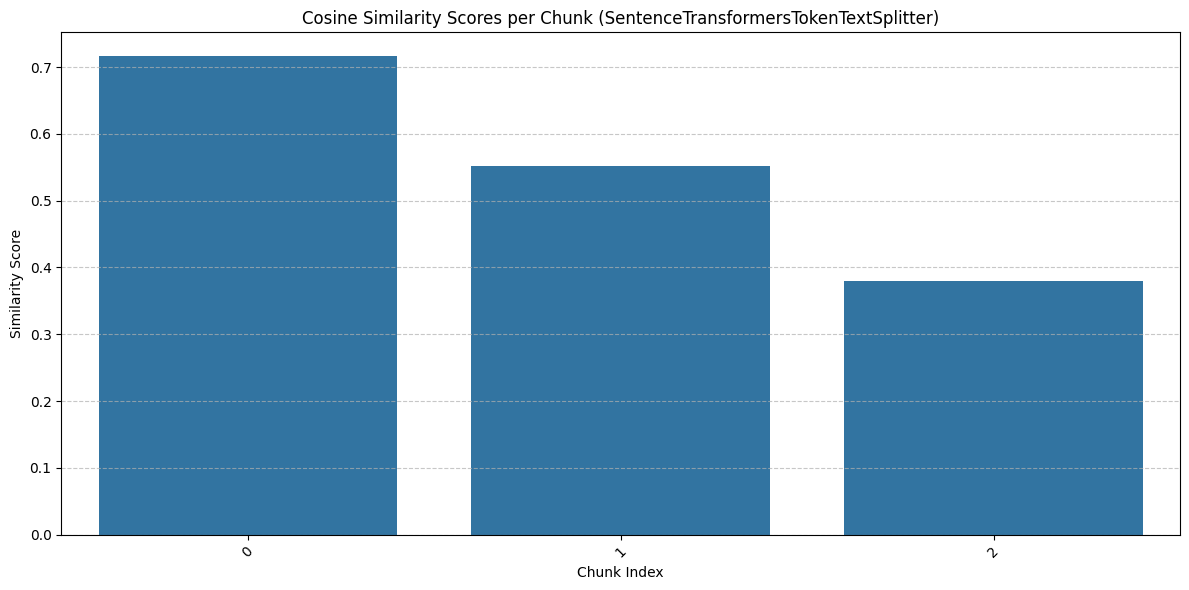

In [ ]:
df_scores_sentence = pd.DataFrame({
    'Chunk Index': range(len(scores_sentence)),
    'Similarity Score': [s for s in scores_sentence]
})

plt.figure(figsize=(12, 6))
sns.barplot(x='Chunk Index', y='Similarity Score', data=df_scores_sentence)
plt.title('Cosine Similarity Scores per Chunk (SentenceTransformersTokenTextSplitter)')
plt.xlabel('Chunk Index')
plt.ylabel('Similarity Score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()